# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the dataset before model development. This step provides insights into the structure of the data, data types, missing values, summary statistics, and the distribution of the target variable.

The analysis also helps identify skewness and potential outliers that may affect model performance.

## Import Libraries

In [2]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

## Load Dataset

In [3]:
DATA_PATH = "../data/feature_engineered_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found.")

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 1384424
Columns: 20


## Dataset Information

Inspect the dataset structure, column data types, and the first few records.

In [4]:
print("Dataset Information")
print("-" * 40)

df.info()

print("\nFirst Five Rows")
print("-" * 40)

df.head()

Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384424 entries, 0 to 1384423
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   record_key             1384424 non-null  object 
 1   carrier_code           1384424 non-null  int64  
 2   start_time             1384424 non-null  object 
 3   end_time               1384424 non-null  object 
 4   rider_total            1384424 non-null  int64  
 5   start_xcoord           1384424 non-null  float64
 6   start_ycoord           1384424 non-null  float64
 7   end_xcoord             1384424 non-null  float64
 8   end_ycoord             1384424 non-null  float64
 9   save_forward_marker    1384424 non-null  int64  
 10  elapsed_seconds        1384424 non-null  int64  
 11  start_hour             1384424 non-null  int64  
 12  day_of_week            1384424 non-null  int64  
 13  month      

,record_key,carrier_code,start_time,end_time,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,save_forward_marker,elapsed_seconds,start_hour,day_of_week,month,is_weekend,is_rush_hour_a1,trip_distance_km,manhattan_distance_km,speed_kmh,is_rush_hour_a2
0,rid2875421,1,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,0,3,0,1,1.498521,1.748741,11.856428,0
1,rid2377394,0,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,6,6,1,0,1.805507,2.443325,9.803659,0
2,rid3504673,1,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,2,4,0,0,1.485498,1.660362,12.465721,0
3,rid2181028,1,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,5,3,1,0,1.188588,1.197479,9.836594,1
4,rid0801584,1,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,0,443,22,5,1,1,0,1.098942,1.559761,8.930458,0


## Missing Values

Check whether the dataset contains missing values after preprocessing.

In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

if missing_values.sum() == 0:
    print("No missing values found.")

No missing values found.


## Summary Statistics

Display descriptive statistics for all numerical features.

In [7]:
df.describe()

,carrier_code,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,save_forward_marker,elapsed_seconds,start_hour,day_of_week,month,is_weekend,is_rush_hour_a1,trip_distance_km,manhattan_distance_km,speed_kmh,is_rush_hour_a2
count,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06,1.384424e+06
mean,5.335179e-01,1.661011e+00,-7.397673e+01,4.075224e+01,-7.397494e+01,4.075287e+01,5.102483e-03,7.317026e+02,1.358042e+01,3.060864e+00,3.500108e+00,2.895356e-01,2.854776e-01,2.911948e+00,3.760464e+00,1.428987e+01,2.402898e-01
std,4.988755e-01,1.312723e+00,6.836626e-02,3.094146e-02,6.912970e-02,3.380837e-02,7.124922e-02,4.481081e+02,6.459008e+00,1.959747e+00,1.679746e+00,4.535470e-01,4.516418e-01,3.292831e+00,4.275481e+00,1.519948e+01,4.272596e-01
min,0.000000e+00,1.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.000000e+00,-7.399203e+01,4.073819e+01,-7.399140e+01,4.073706e+01,0.000000e+00,3.840000e+02,9.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.198238e+00,1.531424e+00,9.077160e+00,0.000000e+00
50%,1.000000e+00,1.000000e+00,-7.398201e+01,4.075438e+01,-7.397998e+01,4.075485e+01,0.000000e+00,6.320000e+02,1.400000e+01,3.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,1.992601e+00,2.566536e+00,1.266687e+01,0.000000e+00
75%,1.000000e+00,2.000000e+00,-7.396843e+01,4.076829e+01,-7.396388e+01,4.077006e+01,0.000000e+00,9.910000e+02,1.900000e+01,5.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,3.486095e+00,4.505967e+00,1.759306e+01,0.000000e+00
max,1.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.391176e+01,1.000000e+00,2.092000e+03,2.300000e+01,6.000000e+00,6.000000e+00,1.000000e+00,1.000000e+00,1.240909e+03,1.335576e+03,9.274837e+03,1.000000e+00


## Target Variable Distribution

Visualize the distribution of the target variable before modeling.

A log-transformed distribution is also plotted to better observe skewed data.

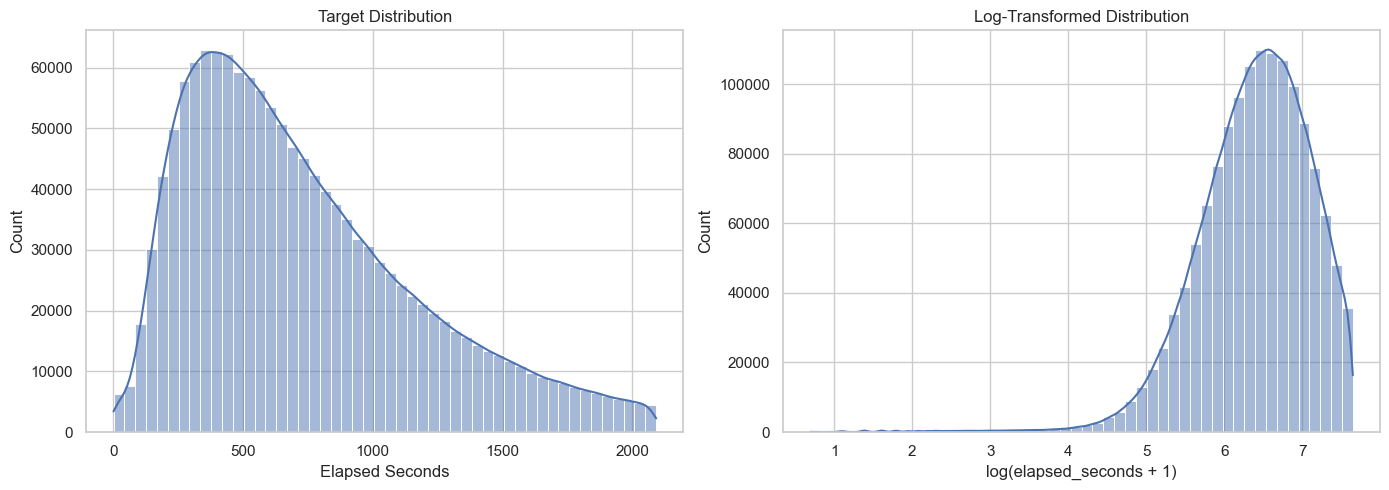

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["elapsed_seconds"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Elapsed Seconds")

sns.histplot(
    np.log1p(df["elapsed_seconds"]),
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(elapsed_seconds + 1)")

plt.tight_layout()

plt.show()

## Target Variable Boxplot

A boxplot is used to visually inspect the distribution of the target variable and identify potential outliers.

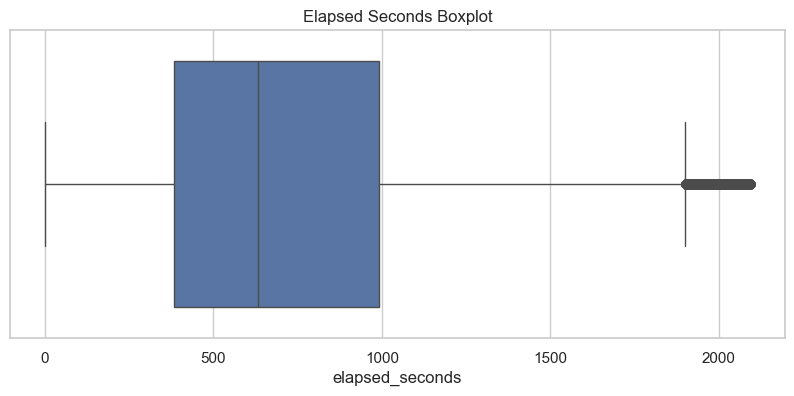

In [9]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["elapsed_seconds"]
)

plt.title("Elapsed Seconds Boxplot")

plt.show()